## XXX model

$$
            H = J \sum_{i} \left( S_i^x S_{i+1}^x + S_i^y S_{i+1}^y + S_i^z S_{i+1}^z \right)
$$

https://journals.aps.org/pr/pdf/10.1103/PhysRev.123.1209

Text(0, 0.5, 'Energy E')

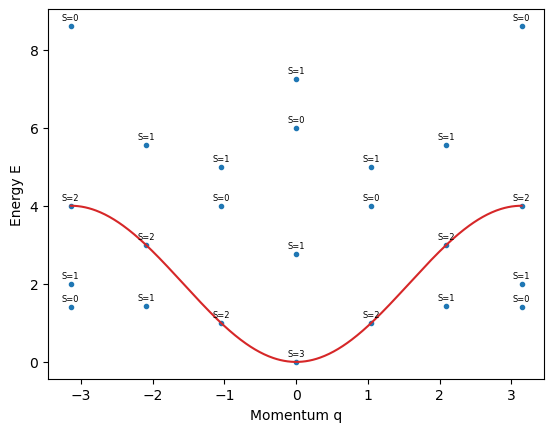

In [2]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt
L = 6
J = 1
ham = qt.generate.operas.heisenberg_operator(L, j=-2*J, cyclic=True) + 2*J*L/4
eng = []
Ss = []
qs = []
for k in range(L):
    q = 2*np.pi/L*k - (0 if k < L/2 else 2*np.pi)
    for S in range(L+1):
        basis = qt.generate.basis.spin_basis(L, Nup=S, kblock=k%L)
        hammat = ham.to_matrix(basis, pauli=False)
        if basis.Ns>0:
            kNeng = np.linalg.eigvalsh(hammat)
            for e in kNeng:
                for i in range(len(eng)):
                    if abs(e - eng[i]) < 1e-10 and abs(qs[i] - q) < 1e-10:
                        Ss[i].append(S)
                        break
                else:
                    eng.append(e)
                    Ss.append([S])
                    qs.append(q)

for i in range(len(qs)):
    if abs(qs[i] + np.pi) < 1e-10:
        eng.append(eng[i])
        Ss.append(Ss[i])
        qs.append(np.pi)

plt.plot(qs, eng, 'C0.')
for i in range(len(eng)):
    si = np.array(Ss[i])
    si = int(max(si/2 - (L-si)/2))
    plt.text(qs[i], eng[i]+0.1, f"S={si}", fontsize=6, ha='center', va='bottom')
xs = np.linspace(-np.pi, np.pi, 500)
plt.plot(xs, 2*J*(1-np.cos(xs)), 'C3-')
plt.xlabel('Momentum q')
plt.ylabel('Energy E')

https://journals.aps.org/pr/pdf/10.1103/PhysRev.128.2131

[ 1.5        -2.11803399  0.11803399 -1.5         1.         -1.         -0.5        -0.         -1.28077641  0.78077641 -0.5         0.5        -2.80277564  0.80277564  0.         -1.28077641  0.78077641  1.         -1.         -0.5        -0.5         0.5        -2.80277564  0.80277564]


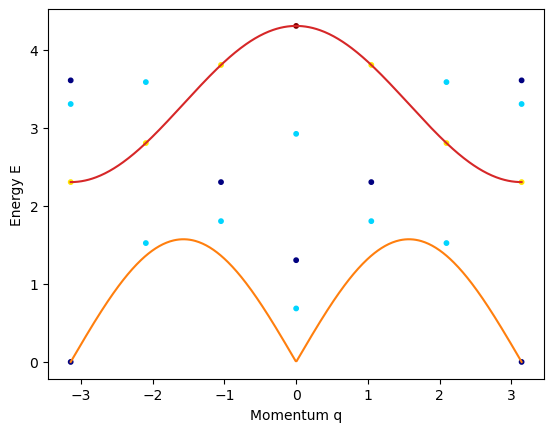

In [4]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt
L = 6
J = 1
ham = qt.generate.operas.heisenberg_operator(L, j=J, cyclic=True)
eng = []
Ss = []
qs = []
for k in range(L):
    q = 2*np.pi/L*k - (0 if k < L/2 else 2*np.pi)
    for S in range(L+1):
        basis = qt.generate.basis.spin_basis(L, Nup=S, kblock=k%L)
        hammat = ham.to_matrix(basis, pauli=False)
        if basis.Ns>0:
            kNeng = np.linalg.eigvalsh(hammat)
            for e in kNeng:
                for i in range(len(eng)):
                    if abs(e - eng[i]) < 1e-10 and abs(qs[i] - q) < 1e-10:
                        Ss[i].append(S)
                        break
                else:
                    eng.append(e)
                    Ss.append([S])
                    qs.append(q)

for i in range(len(qs)):
    if abs(qs[i] + np.pi) < 1e-10:
        eng.append(eng[i])
        Ss.append(Ss[i])
        qs.append(np.pi)

eng = np.array(eng)
print(eng)
eng = eng - min(eng)
color = []
for i in range(len(eng)):
    si = np.array(Ss[i])
    si = int(max(si/2 - (L-si)/2))
    color.append(si)
plt.scatter(qs, eng, c=color, cmap='jet', s=10)
xs = np.linspace(-np.pi, np.pi, 500)
plt.plot(xs, J*np.pi/2*np.abs(np.sin(xs)), 'C1-')
plt.xlabel('Momentum q')
plt.ylabel('Energy E')
xs = np.linspace(-np.pi, np.pi, 500)
plt.plot(xs, -J*(1-np.cos(xs))+max(eng), 'C3-')

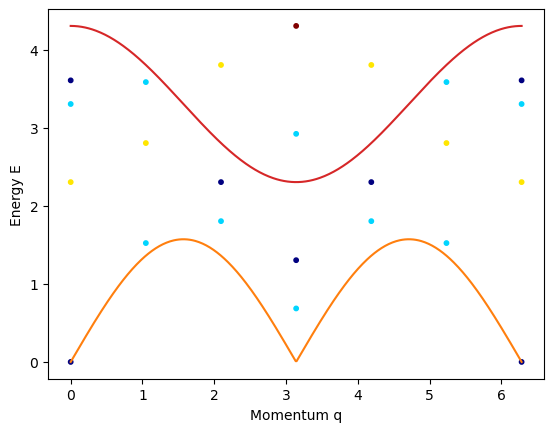

In [184]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt
L = 6
J = 1
ham = qt.generate.operas.heisenberg_operator(L, j=J, cyclic=True)
eng = []
Ss = []
qs = []
for k in range(L):
    if (L//2) % 2 != 0:
        q = 2*np.pi/L*k + (np.pi if k < L/2 else -np.pi)
    else:
        q = 2*np.pi/L*k
    for S in range(L+1):
        basis = qt.generate.basis.spin_basis(L, Nup=S, kblock=k%L)
        hammat = ham.to_matrix(basis, pauli=False)
        if basis.Ns>0:
            kNeng = np.linalg.eigvalsh(hammat)
            for e in kNeng:
                for i in range(len(eng)):
                    if abs(e - eng[i]) < 1e-10 and abs(qs[i] - q) < 1e-10:
                        Ss[i].append(S)
                        break
                else:
                    eng.append(e)
                    Ss.append([S])
                    qs.append(q)

for i in range(len(qs)):
    if abs(qs[i]) < 1e-10:
        eng.append(eng[i])
        Ss.append(Ss[i])
        qs.append(2*np.pi)

eng = np.array(eng)
eng = eng - min(eng)
color = []
for i in range(len(eng)):
    si = np.array(Ss[i])
    si = int(max(si/2 - (L-si)/2))
    color.append(si)
plt.scatter(qs, eng, c=color, cmap='jet', s=10)
xs = np.linspace(0, 2*np.pi, 500)
plt.plot(xs, J*np.pi/2*np.abs(np.sin(xs)), 'C1-')
plt.xlabel('Momentum q')
plt.ylabel('Energy E')
xs = np.linspace(0, 2*np.pi, 500)
plt.plot(xs, -J*(1-np.cos(xs))+max(eng), 'C3-')

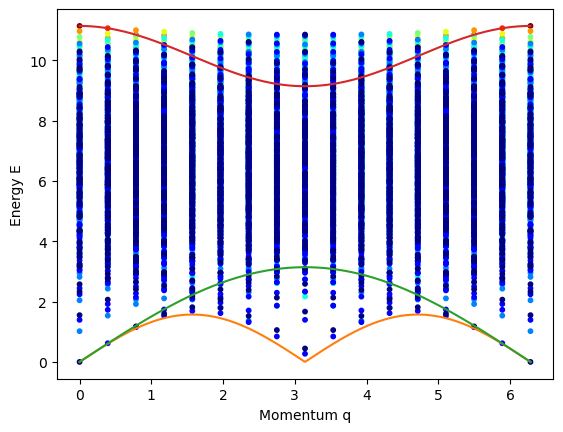

In [189]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt
L = 16
J = 1
ham = qt.generate.operas.heisenberg_operator(L, j=J, cyclic=True)
eng = []
Ss = []
qs = []
for k in range(L):
    if (L//2) % 2 != 0:
        q = 2*np.pi/L*k + (np.pi if k < L/2 else -np.pi)
    else:
        q = 2*np.pi/L*k
    for S in range(L+1):
        basis = qt.generate.basis.spin_basis(L, Nup=S, kblock=k%L)
        hammat = ham.to_matrix(basis, pauli=False)
        if basis.Ns>0:
            kNeng = np.linalg.eigvalsh(hammat)
            for e in kNeng:
                for i in range(len(eng)):
                    if abs(e - eng[i]) < 1e-10 and abs(qs[i] - q) < 1e-10:
                        Ss[i].append(S)
                        break
                else:
                    eng.append(e)
                    Ss.append([S])
                    qs.append(q)

for i in range(len(qs)):
    if abs(qs[i]) < 1e-10:
        eng.append(eng[i])
        Ss.append(Ss[i])
        qs.append(2*np.pi)

eng = np.array(eng)
eng = eng - min(eng)
color = []
for i in range(len(eng)):
    si = np.array(Ss[i])
    si = int(max(si/2 - (L-si)/2))
    color.append(si)
plt.scatter(qs, eng, c=color, cmap='jet', s=10)
xs = np.linspace(0, 2*np.pi, 500)
plt.plot(xs, J*np.pi/2*np.abs(np.sin(xs)), 'C1-')
plt.xlabel('Momentum q')
plt.ylabel('Energy E')
xs = np.linspace(0, 2*np.pi, 500)
plt.plot(xs, J*np.pi*np.abs(np.sin((xs)/2)), 'C2-')
plt.plot(xs, -J*(1-np.cos(xs))+max(eng), 'C3-')

Text(0, 0.5, 'Energy E')

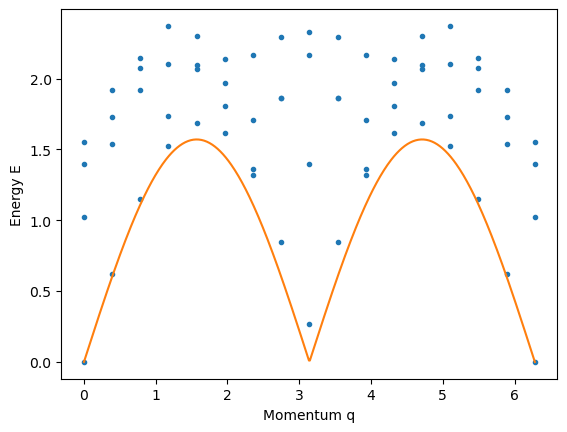

In [230]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
L = 16
J = 1
ham = qt.generate.operas.heisenberg_operator(L, j=J, cyclic=True)
eng = []
Ss = []
qs = []
for k in range(L):
    if (L//2) % 2 != 0:
        q = 2*np.pi/L*k + (np.pi if k < L/2 else -np.pi)
        S = L//2-1 if k!=L//2 else L//2
    else:
        q = 2*np.pi/L*k
        S = L//2-1 if k!=0 else L//2
    basis = qt.generate.basis.spin_basis(L, Nup=S, kblock=k%L)
    hammat = ham.to_matrix(basis, pauli=False, sparse=True)
    if basis.Ns>0:
        kNeng = eigsh(hammat, k=4, which='SA', return_eigenvectors=False)
        eng.append(kNeng)
        qs.append([q]*len(kNeng))
eng = list(np.concatenate(eng))
qs = list(np.concatenate(qs))
for i in range(len(qs)):
    if abs(qs[i]) < 1e-10:
        eng.append(eng[i])
        qs.append(2*np.pi)
eng = np.array(eng)
eng = eng - min(eng)
plt.plot(qs, eng, '.')
xs = np.linspace(0, 2*np.pi, 500)
plt.plot(xs, J*np.pi/2*np.abs(np.sin(xs)), 'C1-')
plt.xlabel('Momentum q')
plt.ylabel('Energy E')
# xs = np.linspace(0, 2*np.pi, 500)
# plt.plot(xs, J*np.pi*np.abs(np.sin((xs)/2)), 'C2-')

In [8]:
import quante as qt

L = 10
mat = qt.generate.matrix.heisenberg_matrix(L, cyclic=True)
mat

array([[2.5, 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1.5, 0.5, ..., 0. , 0. , 0. ],
       [0. , 0.5, 1.5, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 1.5, 0.5, 0. ],
       [0. , 0. , 0. , ..., 0.5, 1.5, 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 2.5]])

In [9]:
builder = qt.generate.operas.SpinBuilder()
for i in range(L):
    builder += 'xx', [i, (i+1) % L], 1.0
    builder += 'yy', [i, (i+1) % L], 1.0
    builder += 'zz', [i, (i+1) % L], 1.0
ham = builder.build()
basis = qt.generate.basis.spin_basis(L)
ham.to_matrix(basis, pauli=False)

array([[2.5, 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1.5, 0.5, ..., 0. , 0. , 0. ],
       [0. , 0.5, 1.5, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 1.5, 0.5, 0. ],
       [0. , 0. , 0. , ..., 0.5, 1.5, 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 2.5]])

In [10]:
import numpy as np
val, vec, _ = qt.linalg.krylov.eigsolve(mat, which='SR')
val

running Lanczos ...


array([-4.51544635])

In [11]:
qt.generate.solvable.heisenberg.xxx_finite_approx_ground_energy(L, j=1.)

np.float64(-4.516244912364189)

In [12]:
L = 20
mat = qt.generate.matrix.heisenberg_matrix(L, sparse=True, cyclic=True)
val, vec, _ = qt.linalg.krylov.eigsolve(mat, which='SR')
val

running Lanczos ...


array([-8.90438653])

In [13]:
qt.generate.solvable.heisenberg.xxx_finite_approx_ground_energy(L, j=1.)

np.float64(-8.904640565028531)

In [14]:
print(qt.generate.solvable.heisenberg.xxx_finite_approx_ground_energy(10000, j=1.)/10000)
print(qt.generate.solvable.heisenberg.xxx_infinite_ground_energy(j=1.))

-0.44314718878856313
-0.4431471805599453


## XX model

$$
    H = \sum_{i = 1}^{L - 1} J_i\left( S_i^x S_{i+1}^x + S_i^y S_{i+1}^y  \right) + \sum_{i = 1}^{L} h^z_i S^z_i
$$

In [15]:
import quante as qt
import numpy as np

L = 10
j = np.random.randn(L-1)
hz = np.random.randn(L)
mat = qt.generate.matrix.heisenberg_matrix(L, j=(j,j,0.), hz=hz)

In [16]:
val, vec, _ = qt.linalg.krylov.eigsolve(mat, which='SR')
val2 = qt.generate.solvable.heisenberg.xy_finite_ground_energy(
    L=L, jx=j, jy=j, jxy=0., jyx=0., hz=hz, pauli=False
)
val, val2

running Lanczos ...


(array([-4.8644144 , -4.81584206]), np.float64(-4.86441439879456))

In [18]:
op = qt.generate.operas.spin
basis = qt.generate.basis.spin_basis(L)
state = qt.generate.state.neel(L, down_first=True)
tlist = np.linspace(0,10,100)
ns = [op.n(i).to_matrix(basis, pauli=False, sparse=True) for i in range(L)]
res1 = qt.linalg.evolve_and_measure(
    mat, state, tlist,
    measure=ns
)
res2 = np.real_if_close(list(qt.generate.solvable.heisenberg.xx_evolve(
    L=L, j=j, h=hz,
    init_state=['dn', 'up']*(L//2),
    tlist=tlist,
    obs_name='particle_number'
)))
np.allclose(res1, res2)

Evolving: 100%|##########| 100/100 [00:00<00:00, 249.02step/s, dt=0.10]


True

In [19]:
op = qt.generate.operas.spin
basis = qt.generate.basis.spin_basis(L)
state = qt.generate.state.neel(L, down_first=True)
tlist = [0,1]
def entanglement(t, state):
    return [qt.measure.entanglement_entropy(state.reshape(-1), left_number=i) for i in range(1,L)]
res1 = qt.linalg.evolve_and_measure(
    mat, state, tlist,
    measure=entanglement
)
res2 = np.real_if_close(list(qt.generate.solvable.heisenberg.xx_evolve(
    L=L, j=j, h=hz,
    init_state=['dn', 'up']*(L//2),
    tlist=tlist,
    obs_name='entanglement'
)))
np.allclose(res1, res2)

Evolving: 100%|##########| 2/2 [00:00<00:00, 500.27step/s, dt=1.00]


True

In [21]:
op = qt.generate.operas.spin
basis = qt.generate.basis.spin_basis(L)
state = qt.generate.state.neel(L, down_first=True)
tlist = [0,1]
def partial_dm(t, state):
    return qt.linalg.partial_trace(state.reshape(-1), dims=[2]*L, keep=[1,2])
res1 = qt.linalg.evolve_and_measure(
    mat, state, tlist,
    measure=partial_dm
)
print(res1[-1])
for s in qt.generate.solvable.heisenberg.xx_evolve(
        L=L, j=j, h=hz,
        init_state=['dn', 'up']*(L//2),
        tlist=tlist,
        obs_name='reduced_density_matrix',
        obs_para=([1,2], None)
    ):
    pass
s

100%|##########| 2/2 [00:00<00:00, 285.79it/s]


[[0.08851763+0.j         0.        +0.j         0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.46532974+0.j         0.1508657 -0.21972857j 0.        +0.j        ]
 [0.        +0.j         0.1508657 +0.21972857j 0.1995739 +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j         0.24657872+0.j        ]]


Evolving: 100%|##########| 2/2 [00:00<00:00, 333.46step/s, dt=1.00]


array([[0.08851763-0.j        , 0.        +0.j        , 0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.46532974-0.j        , 0.1508657 -0.21972857j, 0.        +0.j        ],
       [0.        +0.j        , 0.1508657 +0.21972857j, 0.1995739 +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        , 0.        +0.j        , 0.24657872-0.j        ]])

In [22]:
op = qt.generate.operas.spin
basis = qt.generate.basis.spin_basis(L)
state = qt.generate.state.neel(L, down_first=True)
tlist = [0,1]
def partial_dm(t, state):
    return qt.linalg.partial_trace(state.reshape(-1), dims=[2]*L, keep=[1,2])
res1 = qt.linalg.evolve_and_measure(
    mat, state, tlist,
    measure=partial_dm
)
print(res1[-1])
for s in qt.generate.solvable.heisenberg.xx_evolve(
        L=L, j=j, h=hz,
        init_state=['dn', 'up']*(L//2),
        tlist=tlist,
        obs_name='reduced_density_matrix',
        obs_para=([1,2], None)
    ):
    pass
s

  0%|          | 0/2 [00:00<?, ?it/s]

100%|##########| 2/2 [00:00<00:00, 250.00it/s]


[[0.08851763+0.j         0.        +0.j         0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.46532974+0.j         0.1508657 -0.21972857j 0.        +0.j        ]
 [0.        +0.j         0.1508657 +0.21972857j 0.1995739 +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j         0.24657872+0.j        ]]


Evolving: 100%|##########| 2/2 [00:00<00:00, 285.73step/s, dt=1.00]


array([[0.08851763-0.j        , 0.        +0.j        , 0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.46532974-0.j        , 0.1508657 -0.21972857j, 0.        +0.j        ],
       [0.        +0.j        , 0.1508657 +0.21972857j, 0.1995739 +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        , 0.        +0.j        , 0.24657872-0.j        ]])

## XY model

$$
            H = \sum_{i = 1}^{L - 1} \left(J^x_i S_i^x S_{i+1}^x + J^y_i S_i^y S_{i+1}^y + J^{xy}_i S_i^x S_{i+1}^y + J^{yx}_i S_i^y S_{i+ 1}^x \right) + \sum_{i = 1}^{L} h^z_i S^z_i
$$

In [23]:
import quante as qt
import numpy as np

L = 10
jx = jy = jxy = jyx = hz = 1
jx = np.random.randn(L-1)
# jx = jy
jxy = np.random.randn(L-1)
jyx = np.random.randn(L-1)
hz = np.random.randn(L)
mat = qt.generate.matrix.heisenberg_matrix(L, j=(jx,jy,0.), jxy=jxy, jyx=jyx, hz=hz)

In [24]:
val, vec, _ = qt.linalg.krylov.eigsolve(mat, which='SR')
val2 = qt.generate.solvable.heisenberg.xy_finite_ground_energy(
    L=L, jx=jx, jy=jy, jxy=jxy, jyx=jyx, hz=hz, pauli=False
)
val, val2

running Lanczos ...


(array([-5.44782485, -5.44549067]), np.float64(-5.447824845571595))

In [25]:
val1 = np.linalg.eigvalsh(mat)
val2 = qt.generate.solvable.heisenberg.xy_spectrum(
    L=L, jx=jx, jy=jy, jxy=jxy, jyx=jyx, hz=hz, pauli=False
)
val1, val2

(array([-5.44782485, -5.44549067, -5.22899363, ...,  5.22899363,  5.44549067,  5.44782485]),
 array([-5.44782485, -5.44549067, -5.22899363, ...,  5.22899363,  5.44549067,  5.44782485]))

In [27]:
mat = qt.generate.matrix.heisenberg_matrix(L, j=(jx,jy,0.), jxy=jxy, jyx=jyx, hz=hz)
basis = qt.generate.basis.spin_basis(L)
state = qt.generate.state.neel(L, down_first=True)
tlist = np.linspace(0,10,100)
op = qt.generate.operas.spin
ns = [op.n(i).to_matrix(basis, pauli=False, sparse=True) for i in range(L)]
res1 = qt.linalg.evolve_and_measure(
    mat, state, tlist,
    measure=ns
)
res2 = np.real_if_close(list(qt.generate.solvable.heisenberg.xy_evolve(
    L=L, jx=jx, jy=jy, jxy=jxy, jyx=jyx, hz=hz,
    init_state=['dn', 'up']*(L//2) + ['dn']*(L%2),
    tlist=tlist,
    obs_name='particle_number'
)))
print(res1[-1])
print(res2[-1])


100%|##########| 100/100 [00:00<00:00, 330.33it/s]

[0.39735038 0.42799486 0.1808494  0.74596192 0.34801319 0.57377394 0.4610426  0.34300752 0.36718573 0.74525785]
[0.39735038 0.42799486 0.1808494  0.74596192 0.34801319 0.57377394 0.4610426  0.34300752 0.36718573 0.74525785]
